Text(0.5, 1.0, 'Happiness Score Variance')

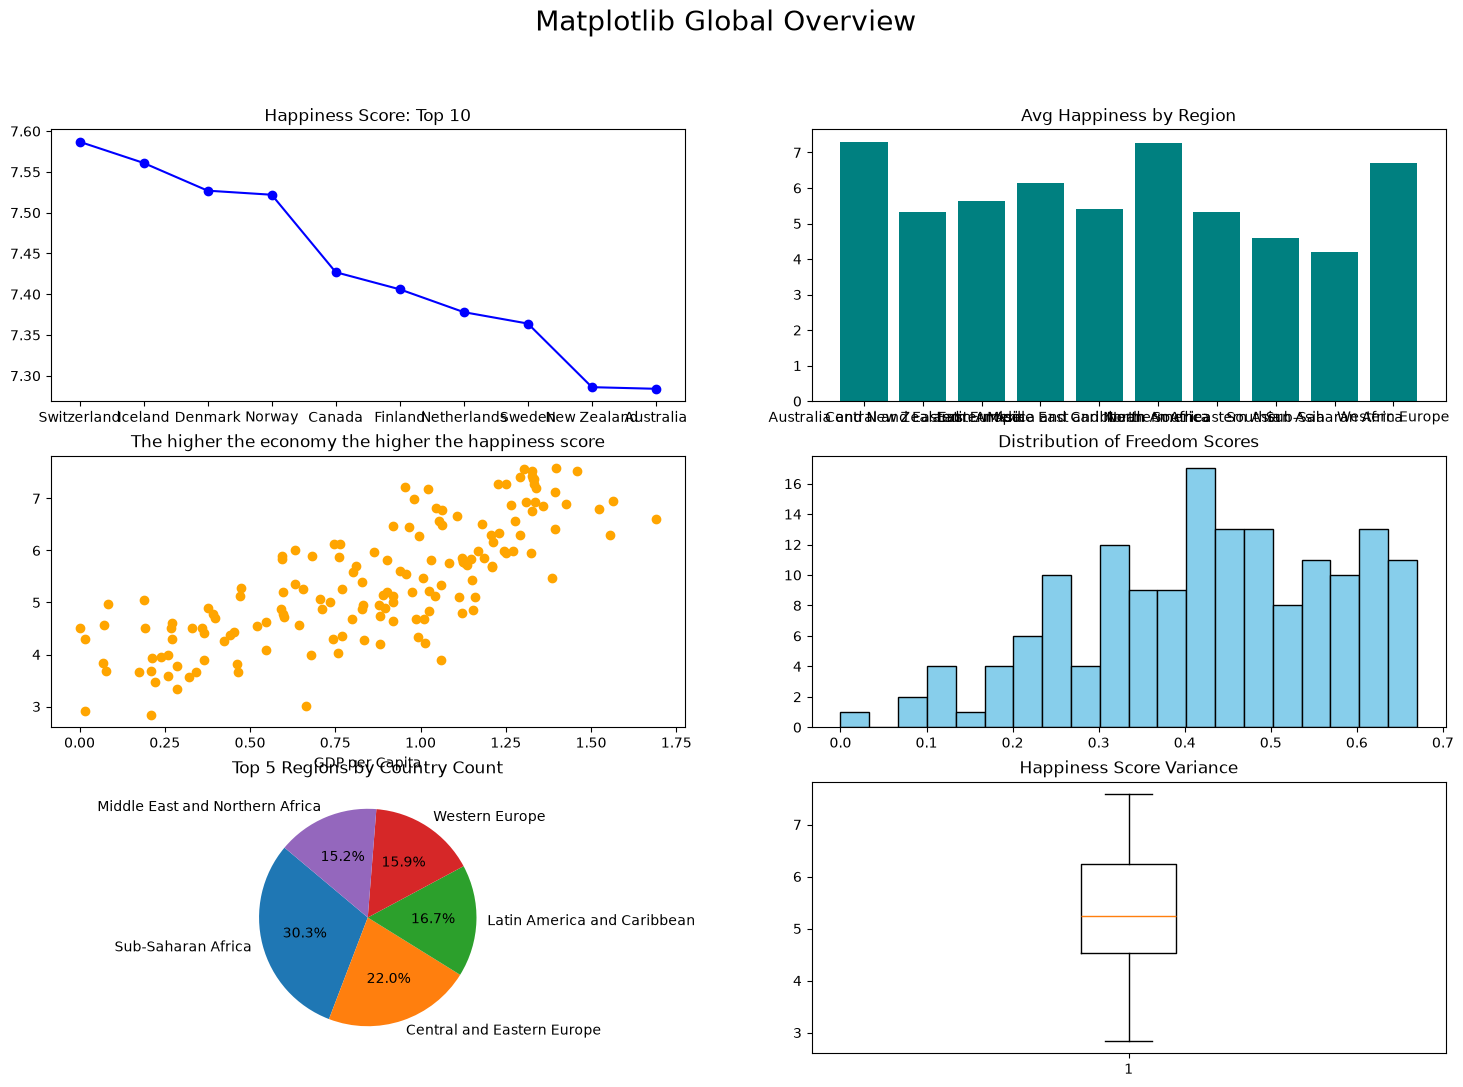

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('./examples/2015.csv')
fig, axes = plt.subplots(3, 2, figsize=(18, 12))
fig.suptitle('Matplotlib Global Overview', fontsize=20)

top_10 = df.head(10)
axes[0, 0].plot(top_10['Country'], top_10['Happiness Score'], marker='o', color='b')
axes[0, 0].set_title('Happiness Score: Top 10')
# axes[0, 0].tick_params(axis='x', rotation=45)

region_avg = df.groupby('Region')['Happiness Score'].mean()
axes[0, 1].bar(region_avg.index, region_avg.values, color='teal')
axes[0, 1].set_title('Avg Happiness by Region')
# axes[0, 1].tick_params(axis='x', rotation=90)

axes[1, 0].scatter(df['Economy (GDP per Capita)'], df['Happiness Score'], color='orange')
axes[1, 0].set_title('The higher the economy the higher the happiness score')
axes[1, 0].set_xlabel('GDP per Capita')

axes[1, 1].hist(df['Freedom'], bins=20, color='skyblue', edgecolor='black')
axes[1, 1].set_title('Distribution of Freedom Scores')

region_counts = df['Region'].value_counts().head(5)
axes[2, 0].pie(region_counts, labels=region_counts.index, autopct='%1.1f%%', startangle=140)
axes[2, 0].set_title('Top 5 Regions by Country Count')

axes[2, 1].boxplot(df['Happiness Score'])
axes[2, 1].set_title('Happiness Score Variance')


Text(0.5, 1.0, 'Distribution of Global Freedom with Density Curve')

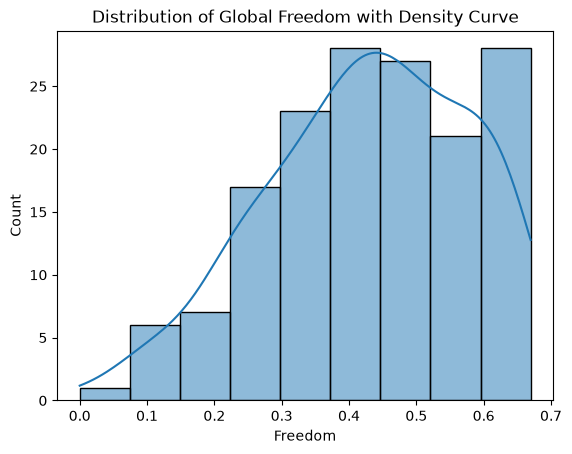

In [36]:
import seaborn as sns

sns.histplot(data=df, x="Freedom", kde=True)
plt.title("Distribution of Global Freedom with Density Curve")


Text(0.5, 1.0, 'Happiness Spread Across Regions')

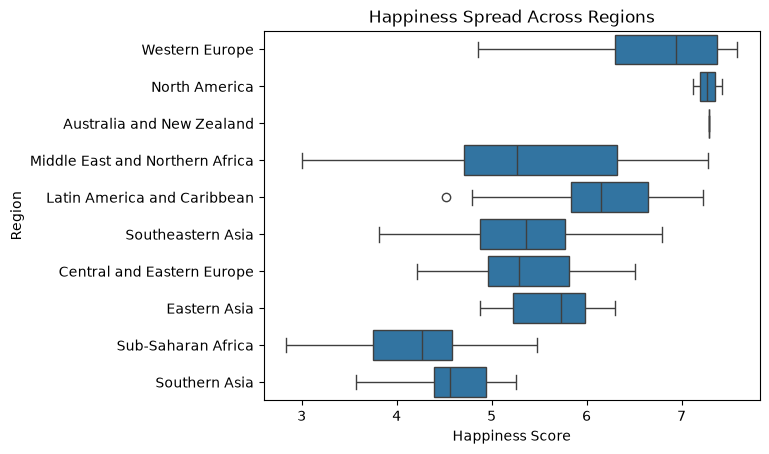

In [40]:
sns.boxplot(data=df, x='Happiness Score', y='Region')
plt.title("Happiness Spread Across Regions")

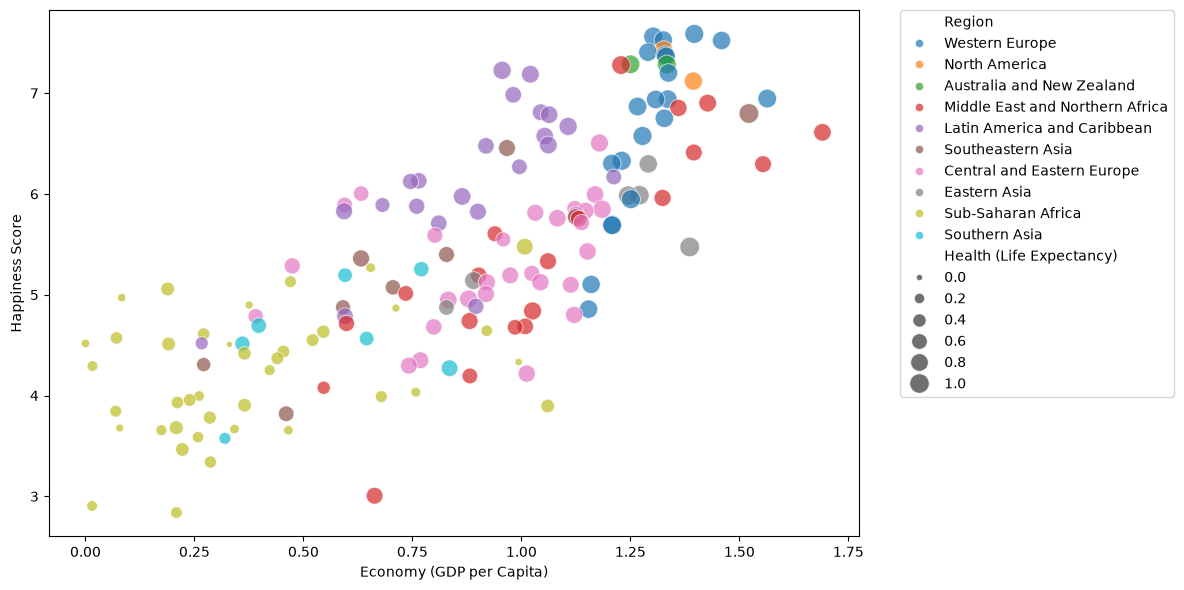

In [56]:
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=df,
    x='Economy (GDP per Capita)',
    y='Happiness Score',
    hue='Region',
    size='Health (Life Expectancy)',
    sizes=(20, 200), 
    alpha=0.7
)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()

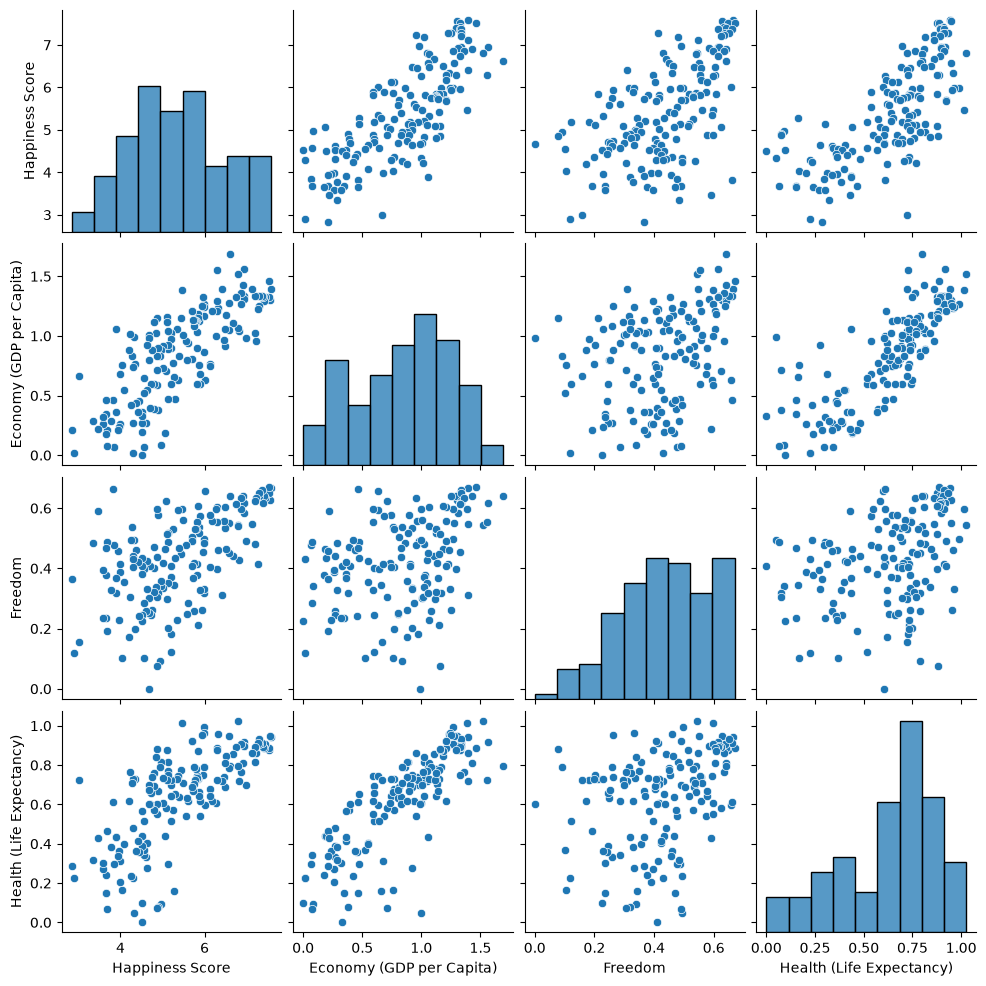

In [57]:
sns.pairplot(df[['Happiness Score', 'Economy (GDP per Capita)', 'Freedom', 'Health (Life Expectancy)']])

<Axes: >

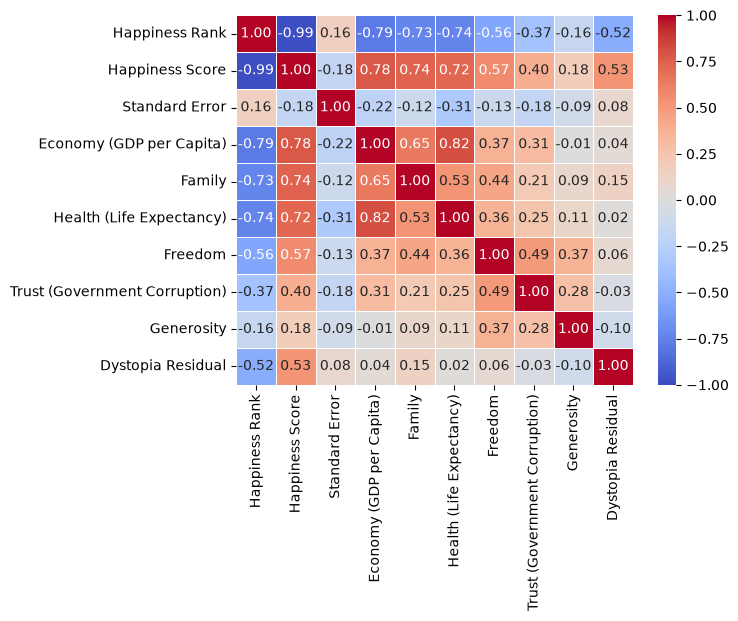

In [62]:
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()
sns.heatmap(
    corr_matrix, 
    annot= True, 
    cmap='coolwarm', 
    fmt=".2f", 
    linewidths=0.5,
    vmin=-1, 
    vmax=1
)